In [25]:
# Import statements
import pandas as pd 
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, f1_score, roc_auc_score
from sklearn.dummy import DummyClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
import sklearn.metrics as metrics

In [4]:
df = pd.read_csv("amazon_cleaned.csv") # Efe provided a cleaned dataset file for the rest of us to work with

# Additional Cleaning and Preprocessing Checks

In [8]:
# Drops categories with 2 or fewer products and removes excess name information
df['category'] = df['category'].str.split('|', expand=True)[0]
categories_to_drop = ['MusicalInstruments', 'HomeImprovement', 'Toys&Games', 'Car&Motorbike', 'Health&PersonalCare']
df = df[~df['category'].isin(categories_to_drop)]

print(df['category'].value_counts())

category
Electronics              526
Computers&Accessories    451
Home&Kitchen             448
OfficeProducts            31
Name: count, dtype: int64


# Exploratory Data Analysis

## Summary Statistics

In [27]:
# Correlation Coefficients Matrix
df.corr(numeric_only=True)

,discounted_price,actual_price,discount_percentage,rating,rating_count,is_deal
discounted_price,1.000000,0.961884,-0.242984,0.115178,-0.027308,0.014669
actual_price,0.961884,1.000000,-0.118319,0.117560,-0.036227,0.083162
discount_percentage,-0.242984,-0.118319,1.000000,-0.132886,0.011388,0.343376
rating,0.115178,0.117560,-0.132886,1.000000,0.099909,0.505105
rating_count,-0.027308,-0.036227,0.011388,0.099909,1.000000,0.115092
is_deal,0.014669,0.083162,0.343376,0.505105,0.115092,1.000000


In [28]:
# Outlier Detection for Price (i.e., IQR or z-score)
print(df.quantile(0.75, numeric_only=True) - df.quantile(0.25, numeric_only=True))

discounted_price        1674.00
actual_price            3549.72
discount_percentage       31.00
rating                     0.30
rating_count           16151.75
is_deal                    1.00
dtype: float64


In [29]:
# Category Cardinality and Per-Category Deal Rate
deals_df = df[(df['is_deal'] == True)]

print("Overall Count:")
print(df['category'].value_counts())
print("\nDeal Count:")
print(deals_df['category'].value_counts())

Overall Count:
category
Electronics              526
Computers&Accessories    451
Home&Kitchen             448
OfficeProducts            31
Name: count, dtype: int64

Deal Count:
category
Computers&Accessories    272
Electronics              246
Home&Kitchen             165
OfficeProducts             4
Name: count, dtype: int64


## Plotted Figures

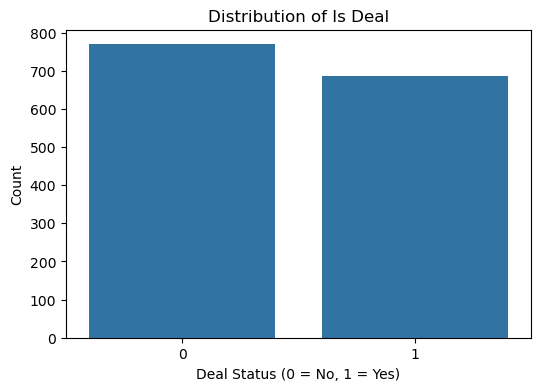

In [10]:
# Bar chart, specifically countplot of "is_deal" distribution
plt.figure(figsize = (6, 4))
sns.countplot(data = df, x = "is_deal")
plt.title("Distribution of Is Deal")
plt.xlabel("Deal Status (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()

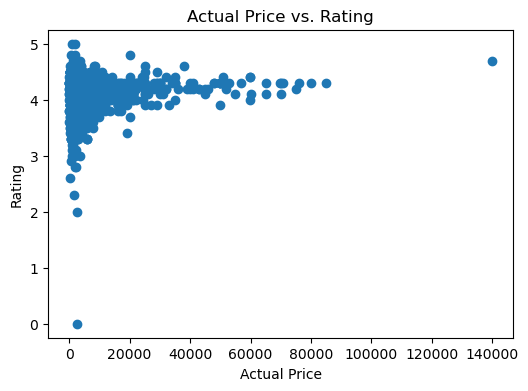

In [11]:
# Scatter Plot of Actual Price vs. Rating
plt.figure(figsize = (6, 4))
plt.scatter(df["actual_price"], df["rating"])
plt.title("Actual Price vs. Rating")
plt.xlabel("Actual Price")
plt.ylabel("Rating")
plt.show()

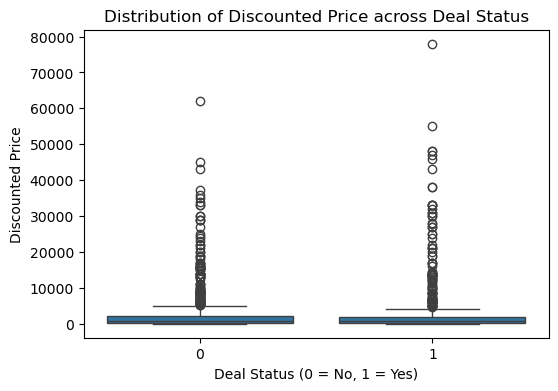

In [12]:
# Box Plot of Discounted Price vs. Is Deal
plt.figure(figsize = (6, 4))
sns.boxplot(x = "is_deal", y = "discounted_price", data = df)
plt.title("Distribution of Discounted Price across Deal Status")
plt.xlabel("Deal Status (0 = No, 1 = Yes)")
plt.ylabel("Discounted Price")
plt.show()

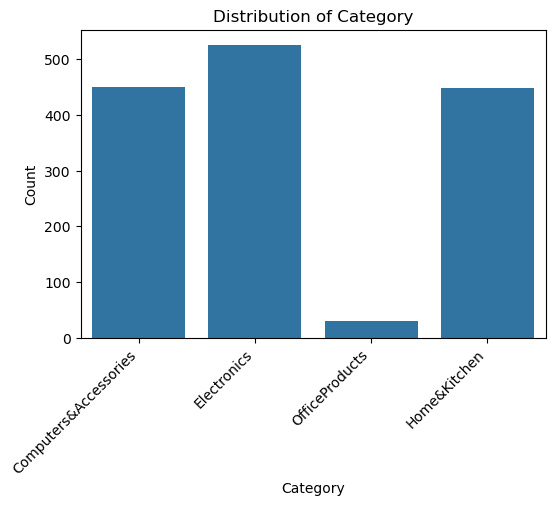

In [13]:
# Bar chart, specifically countplot of category distribution 
plt.figure(figsize = (6, 4))
sns.countplot(data = df, x = "category")
plt.title("Distribution of Category")
plt.xlabel("Category")
plt.ylabel("Count")
plt.xticks(rotation = 45, ha = "right")
plt.show()

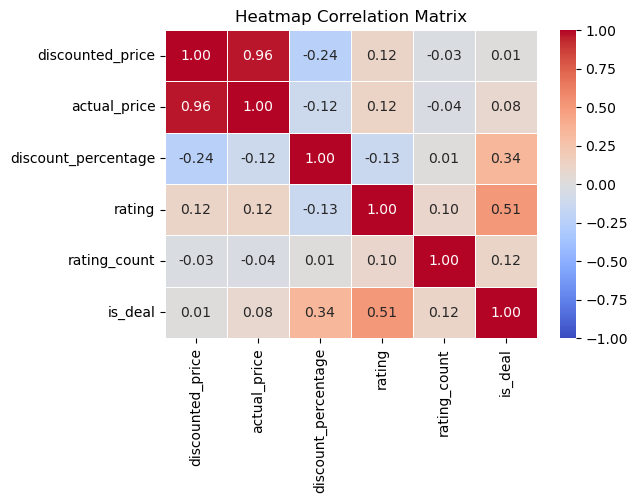

In [14]:
# Heatmap Correlation Matrix
plt.figure(figsize = (6, 4))
corr_matrix = df.select_dtypes(include = [np.number]).corr()
sns.heatmap(corr_matrix, annot = True, cmap = "coolwarm", fmt = ".2f", vmin = -1, vmax = 1,linewidths = 0.5)
plt.title("Heatmap Correlation Matrix")
plt.show()

# Models

## KNN

In [18]:
x = df[["category", "discounted_price", "actual_price", "rating_count"]].copy()
y = df["is_deal"]

x = pd.get_dummies(x, columns=["category"], drop_first=True)

x_train, x_test = train_test_split(
    x, test_size=0.2, random_state=2, stratify=y
)

y_train, y_test = train_test_split(
    y, test_size=0.2, random_state=2, stratify=y
)

#scaling
scaler = StandardScaler()
num_cols = ["discounted_price", "actual_price", "rating_count"]
x_train_scaled = x_train.copy()
x_test_scaled = x_test.copy()

x_train_scaled[num_cols] = scaler.fit_transform(x_train[num_cols])
x_test_scaled[num_cols] = scaler.transform(x_test[num_cols])

In [19]:
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(x_train_scaled, y_train)
y_pred = knn.predict(x_test_scaled)
 
dummy = DummyClassifier(strategy="most_frequent", random_state=2)
dummy.fit(x_train_scaled, y_train)
y_dummy_pred = dummy.predict(x_test_scaled)

In [20]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score

knn_accuracy = accuracy_score(y_test, y_pred)
knn_precision = precision_score(y_test, y_pred)

In [21]:
accuracy_score(y_test, y_pred)

0.6301369863013698

In [22]:
roc_auc_score(y_test, y_pred)

0.6309053265575004

In [23]:
f1_score(y_test, y_pred)

0.6223776223776224

## Multiple Logistic Regression

In [26]:
x = df[['category','discounted_price','actual_price','rating_count']].copy()
y = df['is_deal']

x = pd.get_dummies(x, columns=['category'], drop_first=True)

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=2, stratify=y)

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

model = LogisticRegression()
model.fit(x_train_scaled, y_train)

y_prediction = model.predict(x_test_scaled)
y_probabilities = model.predict_proba(x_test_scaled)[:, 1]

print(f"Accuracy: {metrics.accuracy_score(y_test, y_prediction)}")
print(f"F1-Score: {metrics.f1_score(y_test, y_prediction)}")
print(f"ROC-AUC Score: {metrics.roc_auc_score(y_test, y_probabilities)}")
print(f"Classification Report:\n{metrics.classification_report(y_test, y_prediction)}")

Accuracy: 0.5993150684931506
F1-Score: 0.5517241379310345
ROC-AUC Score: 0.6795125164690381
Classification Report:
              precision    recall  f1-score   support

           0       0.61      0.67      0.64       154
           1       0.59      0.52      0.55       138

    accuracy                           0.60       292
   macro avg       0.60      0.60      0.59       292
weighted avg       0.60      0.60      0.60       292



## Random Forest Classifier

In [30]:
X = df[["category", "discounted_price", "actual_price", "rating_count"]]
y = df["is_deal"]

X = pd.get_dummies(X, columns=["category"], drop_first = True) # One-hot encoding 

# Split into 80/20 Train-Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

# Scaled features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

rfc_model = RandomForestClassifier(n_estimators = 100, max_depth = 10, class_weight = "balanced", random_state = 42)

rfc_model.fit(X_train_scaled, y_train)

rfc_model_predict = rfc_model.predict(X_test_scaled)

rfc_model_prob_score = rfc_model.predict_proba(X_test_scaled)[:, 1]

# Evaluation
print(f"Overall Accuracy: {accuracy_score(y_test, rfc_model_predict)}")
print(f"F1-Score: {f1_score(y_test, rfc_model_predict)}")
print(f"ROC-AUC Score: {roc_auc_score(y_test, rfc_model_prob_score)}")
print(f"Classification Report: \n {classification_report(y_test, rfc_model_predict)}")

Overall Accuracy: 0.7123287671232876
F1-Score: 0.7
ROC-AUC Score: 0.8073838169379571
Classification Report: 
               precision    recall  f1-score   support

           0       0.75      0.70      0.72       157
           1       0.68      0.73      0.70       135

    accuracy                           0.71       292
   macro avg       0.71      0.71      0.71       292
weighted avg       0.71      0.71      0.71       292



## Decision Tree